In [2]:
import pandas as pd
import torch
import sys 
sys.path.append("..")
from torch_geometric import seed_everything
import gc
from models.training_utils import load_feature_dict
from data_class import GNNData
import yaml
from model_class import LinkPredictor
import warnings
warnings.filterwarnings("ignore")
import numpy as np


sys.path.append("..")
from models.training_utils import NegativeSampler 
data_folder = "/biodata/nyanovsky/datasets/dti/processed/v2/"
nodes = pd.read_csv(f"{data_folder}node_df.csv", index_col="node_id")
edges = pd.read_csv(f"{data_folder}edge_df_dedup.csv")

tensor_df = pd.read_csv(f"{data_folder}dti_tensor_df.csv", index_col=0)


full_dataset = torch.load(f"{data_folder}dti_full_dataset.pt")

In [3]:
nodes.head()

,ChG_deg,ChCh_deg,GG_deg,total_deg,node_type,louvain community (nodetype subgraph)
node_id,,,,,,
C155831,1,4,0,5,chem,141
G5243,41,0,17,58,gene,42
C24762158,9,2,0,11,chem,489
G213,85,0,3,88,gene,2
G506,6,0,3,9,gene,93


In [4]:
edges.head()

,src_id,trgt_id,edge_type,src_node_type,trgt_node_type,src_node_index,trgt_node_index
0,C155831,G5243,chg,chem,gene,0,1
1,C24762158,G213,chg,chem,gene,2,3
2,C24762158,G506,chg,chem,gene,2,4
3,C24762158,G563,chg,chem,gene,2,5
4,C24762158,G13884,chg,chem,gene,2,6


In [5]:
full_data = GNNData(node_path="/biodata/nyanovsky/datasets/dti/processed/v2/node_df.csv",
               edge_path="/biodata/nyanovsky/datasets/dti/processed/v2/edge_df_dedup.csv",
               node_index_col="node_id",
               src_edge_col="src_id",
               dst_edge_col="trgt_id",
               node_type_col="node_type",
               edge_type_col="edge_type",
               src_node_type_col="src_node_type",
               dst_node_type_col="trgt_node_type")

In [6]:
no_chch_data = GNNData(node_path="/biodata/nyanovsky/datasets/dti/processed/v2/node_df.csv",
               edge_path="/biodata/nyanovsky/datasets/dti/processed/v2/edges_no_chch.csv",
               node_index_col="node_id",
               src_edge_col="src_id",
               dst_edge_col="trgt_id",
               node_type_col="node_type",
               edge_type_col="edge_type",
               src_node_type_col="src_node_type",
               dst_node_type_col="trgt_node_type")

no_gg_data = GNNData(node_path="/biodata/nyanovsky/datasets/dti/processed/v2/node_df.csv",
               edge_path="/biodata/nyanovsky/datasets/dti/processed/v2/edges_no_gg.csv",
               node_index_col="node_id",
               src_edge_col="src_id",
               dst_edge_col="trgt_id",
               node_type_col="node_type",
               edge_type_col="edge_type",
               src_node_type_col="src_node_type",
               dst_node_type_col="trgt_node_type")

only_dti_data = GNNData(node_path="/biodata/nyanovsky/datasets/dti/processed/v2/node_df.csv",
               edge_path="/biodata/nyanovsky/datasets/dti/processed/v2/edges_chg.csv",
               node_index_col="node_id",
               src_edge_col="src_id",
               dst_edge_col="trgt_id",
               node_type_col="node_type",
               edge_type_col="edge_type",
               src_node_type_col="src_node_type",
               dst_node_type_col="trgt_node_type")

In [7]:
supervision_edge_type = ("chem", "chg", "gene")
gene_feature_dict = load_feature_dict(data_folder+"prot_features_64.txt", data_folder+"prot_features_ids.txt", 
                                                    tensor_df, "gene")

In [8]:
configs_folder = "/biodata/nyanovsky/datasets/dti/best_models/"
with open(configs_folder+"sage_config.yaml","r") as file:
    sage_config = yaml.safe_load(file)

sage_config["train"].pop("epochs")
sage_config["train"].pop("feature_dim")
sage_config["train"].pop("features")

'go2vec'

In [9]:
datasets = [full_data, no_chch_data, no_gg_data, only_dti_data]
samplers = [NegativeSampler(dataset.data, supervision_edge_type, 
                            dataset.data["chem"].degrees_by_edge_type[supervision_edge_type],
                            dataset.data["gene"].degrees_by_edge_type[supervision_edge_type])
                            for dataset in datasets]

In [10]:
'''
results_df = pd.DataFrame(index=["with_features", "without_features"], columns=["full", "no_chch", "no_gg", "only_dti"])
for feat in results_df.index:
    for name,net, sampler in zip(results_df.columns, datasets, samplers):
        aucs = []

        if feat == "with_features":
            net.initialize_features(64, gene_feature_dict, inplace=True)
        else:
            net.initialize_features(64, feature_dict=None, inplace=True)
            
        for i in range(10):
            seed_everything(i)
            train, val, test = net.split_data(task="link_prediction", supervision_edge_type=supervision_edge_type, 
                                 negative_sampler=sampler,
                                 disjoint_train_ratio=0.2, 
                                 num_val=0.1,
                                 num_test=0.1)
            splits = {"train":train, "val":val, "test":test}
            model.train(splits, sampler, supervision_edge_type, 500)
            auc = model.evaluate(test)['roc_auc']
            aucs.append(auc)

            model.reset()
            del model 
            del splits 
            gc.collect()
            torch.cuda.empty_cache()

            model = LinkPredictor(conv_name="SAGE",
                      gral_params=sage_config["gral"],
                      conv_params=sage_config["conv"],
                      optimizer_params=sage_config["train"])
            
        results_df.loc[feat,name] = aucs
        print(f"{name} {feat} mean auc: {np.mean(aucs)}")'''

'\nresults_df = pd.DataFrame(index=["with_features", "without_features"], columns=["full", "no_chch", "no_gg", "only_dti"])\nfor feat in results_df.index:\n    for name,net, sampler in zip(results_df.columns, datasets, samplers):\n        aucs = []\n\n        if feat == "with_features":\n            net.initialize_features(64, gene_feature_dict, inplace=True)\n        else:\n            net.initialize_features(64, feature_dict=None, inplace=True)\n            \n        for i in range(10):\n            seed_everything(i)\n            train, val, test = net.split_data(task="link_prediction", supervision_edge_type=supervision_edge_type, \n                                 negative_sampler=sampler,\n                                 disjoint_train_ratio=0.2, \n                                 num_val=0.1,\n                                 num_test=0.1)\n            splits = {"train":train, "val":val, "test":test}\n            model.train(splits, sampler, supervision_edge_type, 500)\n        

In [11]:
seed_everything(42)
only_dti_data.initialize_features(64, feature_dict=None, inplace=True)

In [12]:
def get_seed_results(seed, net, sampler, deterministic_sampling=False):
    model = LinkPredictor(conv_name="SAGE",
                      gral_params=sage_config["gral"],
                      conv_params=sage_config["conv"],
                      optimizer_params=sage_config["train"])
    seed_everything(seed)
    train, val, test = net.split_data(task="link_prediction", supervision_edge_type=supervision_edge_type, 
                                 negative_sampler=sampler,
                                 disjoint_train_ratio=0.2, 
                                 num_val=0.1,
                                 num_test=0.1)
    splits = {"train":train, "val":val, "test":test}
    model.train(splits, sampler, supervision_edge_type, 500, deterministic_sampling)

    return model, splits
    

In [12]:
for seed in range(10):
    model, splits = get_seed_results(seed, only_dti_data, samplers[-1], True)
    print(f"seed {seed} auc = {model.evaluate(splits['test'])['roc_auc']}")
    model.reset()
    del model
    del splits 
    gc.collect()
    with torch.no_grad():
        torch.cuda.empty_cache()    

seed 0 auc = 0.919
seed 1 auc = 0.569
seed 2 auc = 0.567
seed 3 auc = 0.572
seed 4 auc = 0.572
seed 5 auc = 0.923
seed 6 auc = 0.922
seed 7 auc = 0.921
seed 8 auc = 0.566
seed 9 auc = 0.912


In [14]:
for seed in range(10):
    for i in range(10):
        model, splits = get_seed_results(seed, only_dti_data, samplers[-1])
        print(f"seed {seed}, it {i} auc = {model.evaluate(splits['test'])['roc_auc']}")
        model.reset()
        del model
        del splits 
        gc.collect()
        with torch.no_grad():
            torch.cuda.empty_cache()    

seed 0, it 0 auc = 0.917
seed 0, it 1 auc = 0.918
seed 0, it 2 auc = 0.919
seed 0, it 3 auc = 0.918
seed 0, it 4 auc = 0.921
seed 0, it 5 auc = 0.915
seed 0, it 6 auc = 0.918
seed 0, it 7 auc = 0.912
seed 0, it 8 auc = 0.915
seed 0, it 9 auc = 0.919
seed 1, it 0 auc = 0.569
seed 1, it 1 auc = 0.569
seed 1, it 2 auc = 0.569
seed 1, it 3 auc = 0.569
seed 1, it 4 auc = 0.569
seed 1, it 5 auc = 0.569
seed 1, it 6 auc = 0.569
seed 1, it 7 auc = 0.569
seed 1, it 8 auc = 0.569
seed 1, it 9 auc = 0.569
seed 2, it 0 auc = 0.567
seed 2, it 1 auc = 0.567
seed 2, it 2 auc = 0.567
seed 2, it 3 auc = 0.567
seed 2, it 4 auc = 0.567
seed 2, it 5 auc = 0.567
seed 2, it 6 auc = 0.567
seed 2, it 7 auc = 0.567
seed 2, it 8 auc = 0.567
seed 2, it 9 auc = 0.567
seed 3, it 0 auc = 0.572
seed 3, it 1 auc = 0.572
seed 3, it 2 auc = 0.572
seed 3, it 3 auc = 0.572
seed 3, it 4 auc = 0.572
seed 3, it 5 auc = 0.572
seed 3, it 6 auc = 0.572
seed 3, it 7 auc = 0.572
seed 3, it 8 auc = 0.572
seed 3, it 9 auc = 0.572


In [13]:
def get_split_deg_data(split):
    src_type, _, dst_type = supervision_edge_type
    deg_data = {} 
    for split, data in split.items():
        data.to("cpu")
        sup_edge_index = data.edge_label_index_dict[supervision_edge_type]
        pos_idxs = data.edge_label_dict[supervision_edge_type]==1
        neg_idxs = data.edge_label_dict[supervision_edge_type]==0
        src_degs = [only_dti_data.node_df.loc[only_dti_data.rev_node_mappings[src_type][idx],"ChG_deg"] for idx in sup_edge_index[0].numpy()]
        dst_degs = [only_dti_data.node_df.loc[only_dti_data.rev_node_mappings[dst_type][idx],"ChG_deg"] for idx in sup_edge_index[1].numpy()]

        degs = torch.tensor([src_degs, dst_degs])
        deg_data[split] = {"pos":degs[:,pos_idxs], "neg":degs[:,neg_idxs]}
    return deg_data
        


In [14]:
model_0, split_0 = get_seed_results(0, only_dti_data, samplers[-1])
model_1, split_1 = get_seed_results(1, only_dti_data, samplers[-1])

print(model_0.evaluate(split_0["test"]))
print(model_1.evaluate(split_1["test"]))

print(model_0.evaluate(split_1["test"]))
print(model_1.evaluate(split_0["test"]))

{'loss': 0.352186918258667, 'roc_auc': 0.92}
{'loss': 0.6857051253318787, 'roc_auc': 0.569}
{'loss': 0.36028847098350525, 'roc_auc': 0.916}
{'loss': 0.6855230927467346, 'roc_auc': 0.57}


In [51]:
split_0["val"]["chem"].num_nodes

5854

In [57]:
def get_split_induced_degrees(splits):
    src, _, dst = supervision_edge_type 
    induced_degs = {src:{}, dst:{}}
    n_src = splits["train"][src].num_nodes
    n_dst = splits["train"][dst].num_nodes
    for split, data in splits.items():
        split_edge_index = data[supervision_edge_type].edge_index

        induced_degs[src][split] = {}
        for i in range(n_src):
            deg_split_i = len(split_edge_index[1, split_edge_index[0]==i])
            induced_degs[src][split][i] = deg_split_i
        
        induced_degs[dst][split] = {}
        for j in range(n_dst):
            deg_split_j = len(split_edge_index[0, split_edge_index[1]==j])
            induced_degs[dst][split][j] = deg_split_j
        
    return induced_degs 


In [59]:
induced_split_degs_0 = get_split_induced_degrees(split_0)
induced_split_degs_1 = get_split_induced_degrees(split_1)

In [60]:
induced_split_degs_0

{'chem': {'train': {0: 0,
   1: 6,
   2: 2,
   3: 8,
   4: 1,
   5: 0,
   6: 2,
   7: 1,
   8: 2,
   9: 2,
   10: 1,
   11: 4,
   12: 1,
   13: 5,
   14: 6,
   15: 2,
   16: 2,
   17: 0,
   18: 0,
   19: 1,
   20: 0,
   21: 1,
   22: 0,
   23: 1,
   24: 0,
   25: 2,
   26: 1,
   27: 0,
   28: 1,
   29: 2,
   30: 1,
   31: 18,
   32: 2,
   33: 1,
   34: 1,
   35: 2,
   36: 1,
   37: 2,
   38: 0,
   39: 1,
   40: 1,
   41: 1,
   42: 1,
   43: 2,
   44: 3,
   45: 1,
   46: 3,
   47: 0,
   48: 1,
   49: 1,
   50: 3,
   51: 0,
   52: 3,
   53: 4,
   54: 1,
   55: 0,
   56: 1,
   57: 1,
   58: 2,
   59: 1,
   60: 1,
   61: 0,
   62: 6,
   63: 1,
   64: 4,
   65: 0,
   66: 2,
   67: 2,
   68: 1,
   69: 5,
   70: 0,
   71: 0,
   72: 1,
   73: 1,
   74: 3,
   75: 4,
   76: 5,
   77: 4,
   78: 11,
   79: 0,
   80: 1,
   81: 3,
   82: 1,
   83: 1,
   84: 2,
   85: 1,
   86: 0,
   87: 2,
   88: 1,
   89: 1,
   90: 7,
   91: 1,
   92: 1,
   93: 2,
   94: 1,
   95: 1,
   96: 1,
   97: 5,
   98: 1,
 

In [61]:
def get_induced_edge_degrees(split):
    src_type, _, dst_type = supervision_edge_type
    deg_data = {} 
    induced_node_degs = get_split_induced_degrees(split)
    for split, data in split.items():
        data.to("cpu")
        sup_edge_index = data.edge_label_index_dict[supervision_edge_type]
        pos_idxs = data.edge_label_dict[supervision_edge_type]==1
        neg_idxs = data.edge_label_dict[supervision_edge_type]==0
        src_degs = [induced_node_degs[src_type][split][idx] for idx in sup_edge_index[0].numpy()]
        dst_degs = [induced_node_degs[dst_type][split][idx] for idx in sup_edge_index[1].numpy()]

        degs = torch.tensor([src_degs, dst_degs])
        deg_data[split] = {"pos":degs[:,pos_idxs].sum(dim=0), "neg":degs[:,neg_idxs].sum(dim=0)}
    return deg_data

In [62]:
induced_edge_degs_0 = get_induced_edge_degrees(split_0)
induced_edge_degs_1 = get_induced_edge_degrees(split_1)

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

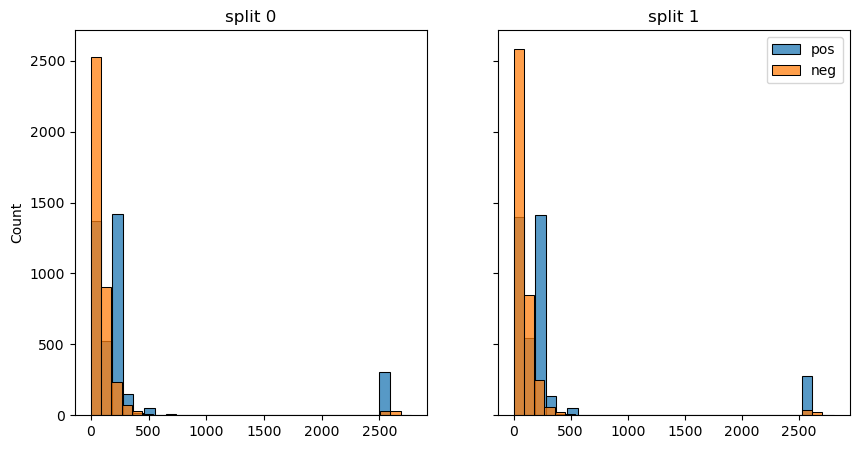

In [69]:
fig, axes = plt.subplots(1,2, sharey=True, figsize=(10,5))
sns.histplot(induced_edge_degs_0["test"]["pos"], ax = axes[0], bins=30, label="pos")
sns.histplot(induced_edge_degs_0["test"]["neg"], ax=axes[0],bins=30, label="neg")
axes[0].set_title("split 0")
sns.histplot(induced_edge_degs_1["test"]["pos"], ax = axes[1], bins=30, label="pos")
sns.histplot(induced_edge_degs_1["test"]["neg"], ax=axes[1],bins=30, label="neg")
axes[1].set_title("split 1")
plt.legend()

In [20]:
adj_train_0 = split_0["train"][supervision_edge_type].adj_t.to_dense()

In [21]:
three_walks_0_train = adj_train_0 @ adj_train_0.t() @ adj_train_0

In [21]:
dist_3_train_1 = split_1["train"][supervision_edge_type].adj_t @ split_1["train"][supervision_edge_type].adj_t.t() @ split_1["train"][supervision_edge_type].adj_t


In [38]:
dist_3_train_0 = torch.cat([row for row in dist_3_train_0.to_dense()])

In [41]:
dist_3_train_1 = torch.cat([row for row in dist_3_train_1.to_dense()])
